# Marketing Campaign Performance Insights
## Python Data Analysis Assignment
---

## 1. Load the Dataset

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

url = 'https://raw.githubusercontent.com/ArchanaInsights/Datasets/main/marketing_campaign.csv'
df = pd.read_csv(url)
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,TechCorp,Email,Women 25-34,30 days,Facebook,5.294194,9344,62.94,Houston,English,3045,67836,5,Tech Enthusiasts,01-01-2023
1,2,Innovate Industries,Influencer,Women 35-44,45 days,Google Ads,3.326375,8783,10.67,"Washington, D.C.",German,1944,66361,4,Foodies,01-01-2023
2,3,NexGen Systems,Social Media,Women 25-34,45 days,Instagram,4.056375,9111,73.20,Miami,Spanish,3156,86240,8,Fashionistas,01-01-2023
3,4,Innovate Industries,Email,Women 25-34,45 days,Instagram,4.496375,7420,60.92,Seattle,Spanish,2388,58251,6,Foodies,01-01-2023
4,5,Data Tech Solutions,Influencer,Men 25-34,30 days,Google Ads,4.405930,2146,138.82,Chicago,English,1025,34407,5,Tech Enthusiasts,01-01-2023


## 2. Descriptive Analysis

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.describe()

In [25]:
df['Campaign_ID'].nunique()

22029

In [27]:
df['Location'].unique()

array(['Houston', 'Washington, D.C.', 'Miami', 'Seattle', 'Chicago',
       'Los Angeles', 'Atlanta', 'Dallas', 'New York', 'San Francisco'],
      dtype=object)

In [29]:
df['Customer_Segment'].unique()

array(['Tech Enthusiasts', 'Foodies', 'Fashionistas',
       'Outdoor Adventurers', 'Health & Wellness'], dtype=object)

In [31]:
df['Campaign_Type'].value_counts()

Campaign_Type
Display         4450
Search          4441
Social Media    4412
Email           4388
Influencer      4338
Name: count, dtype: int64

In [35]:
df['Channel_Used'].value_counts()

Channel_Used
Facebook      3742
Google Ads    3694
Website       3688
Instagram     3649
YouTube       3632
Email         3624
Name: count, dtype: int64

## 3. Exploratory Data Analysis (EDA)

### 1️⃣ Acquisition Cost vs ROI (Scatter Plot)

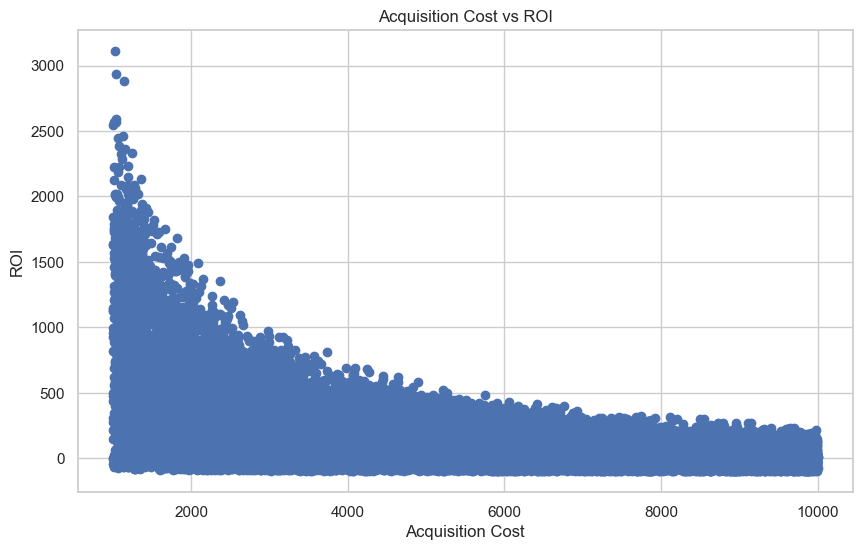

In [79]:
plt.scatter(df['Acquisition_Cost'], df['ROI'])
plt.xlabel('Acquisition Cost')
plt.ylabel('ROI')
plt.title('Acquisition Cost vs ROI')
plt.show()

### 2️⃣ Average Conversion Rate by Channel & Campaign Type

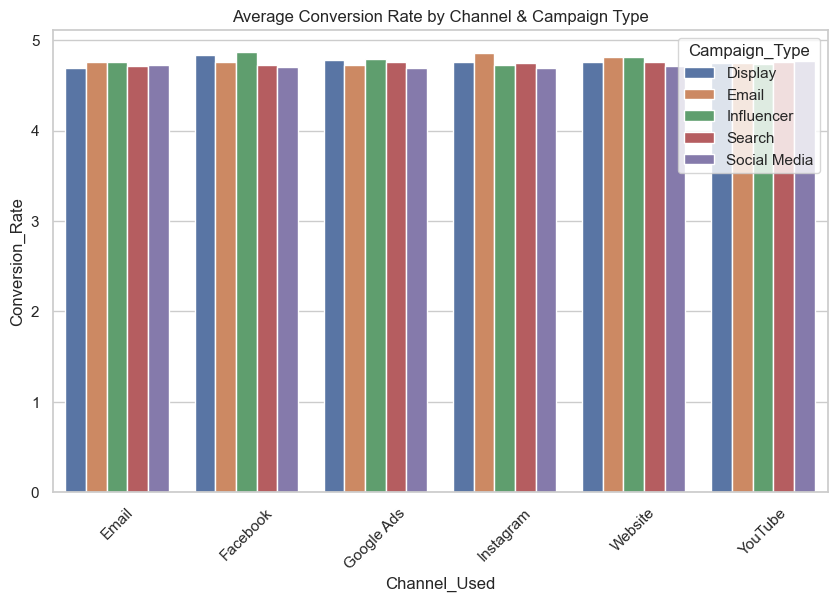

In [81]:
avg_conv = df.groupby(['Channel_Used','Campaign_Type'])['Conversion_Rate'].mean().reset_index()
sns.barplot(data=avg_conv, x='Channel_Used', y='Conversion_Rate', hue='Campaign_Type')
plt.xticks(rotation=45)
plt.title('Average Conversion Rate by Channel & Campaign Type')
plt.show()

### 3️⃣ Engagement Score Distribution (Box Plot)

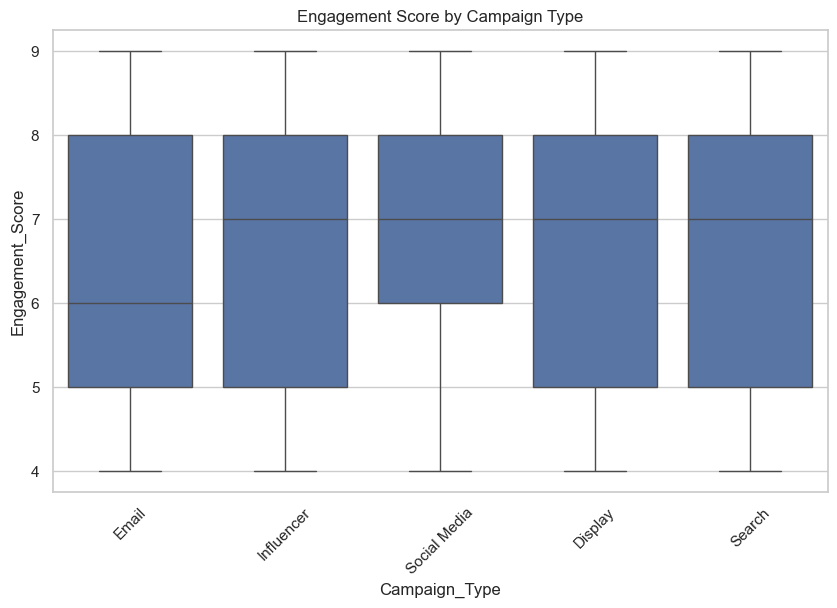

In [83]:
sns.boxplot(data=df, x='Campaign_Type', y='Engagement_Score')
plt.xticks(rotation=45)
plt.title('Engagement Score by Campaign Type')
plt.show()

### 4️⃣ Average ROI by Company

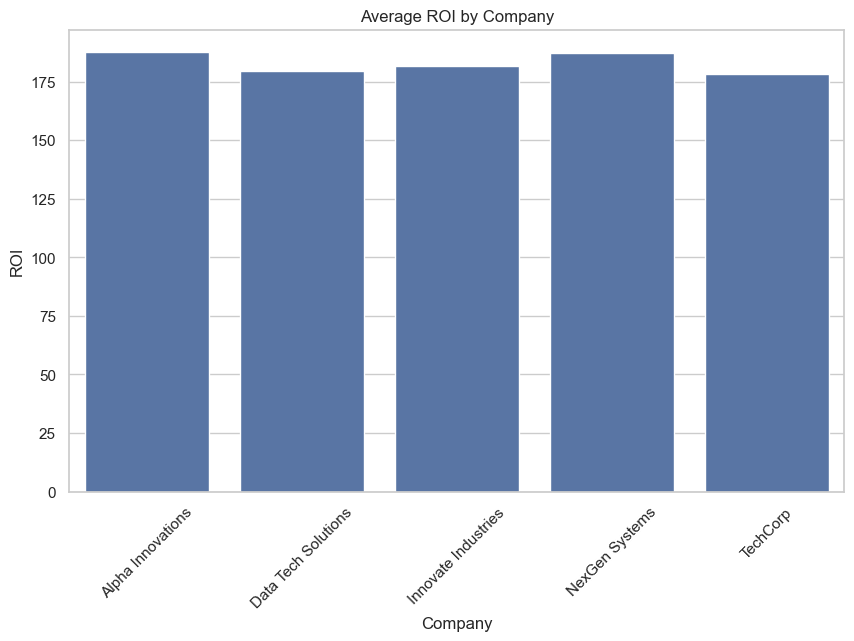

In [85]:
company_roi = df.groupby('Company')['ROI'].mean().reset_index()
sns.barplot(data=company_roi, x='Company', y='ROI')
plt.xticks(rotation=45)
plt.title('Average ROI by Company')
plt.show()

### 5️⃣ Correlation Heatmap (Engagement & Conversion)

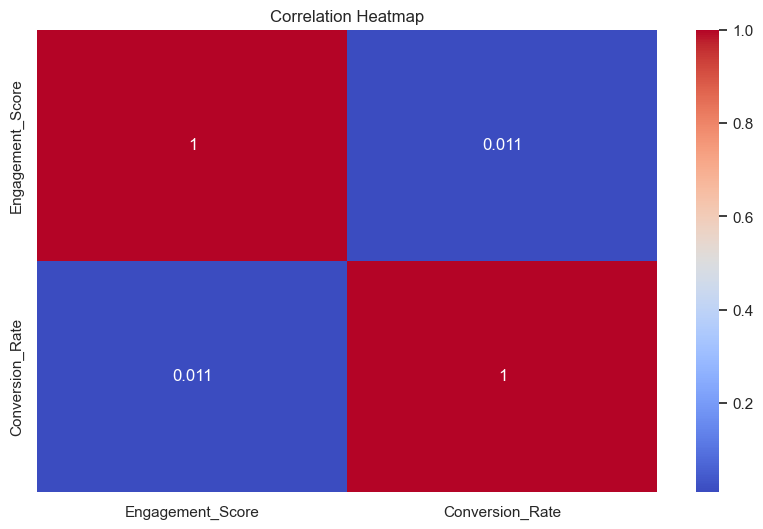

In [87]:
corr = df[['Engagement_Score','Conversion_Rate']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### 6️⃣ Target Audience Distribution

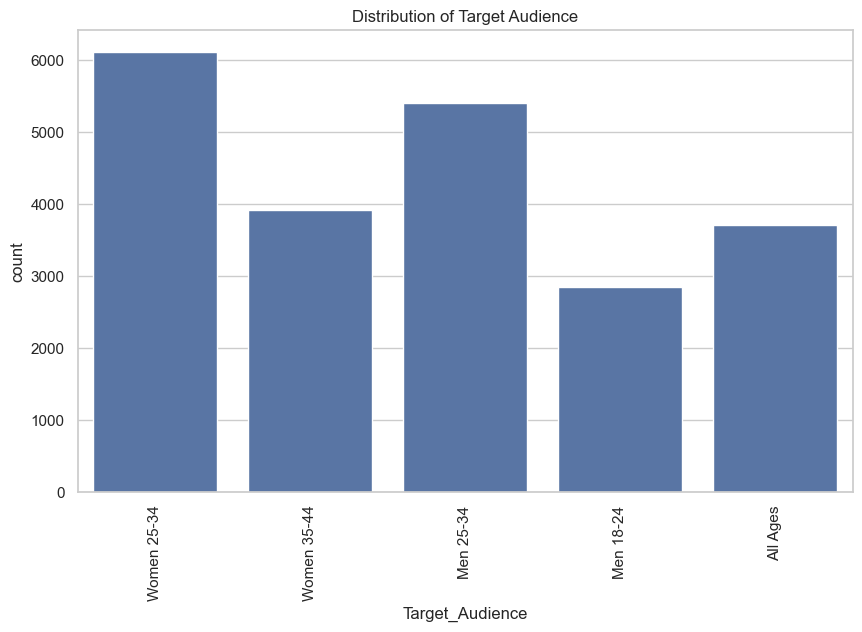

In [89]:
sns.countplot(data=df, x="Target_Audience")
plt.xticks(rotation=90)
plt.title("Distribution of Target Audience")
plt.show()

### 7️⃣ Highest Conversion Rate by Customer Segment for Each Language

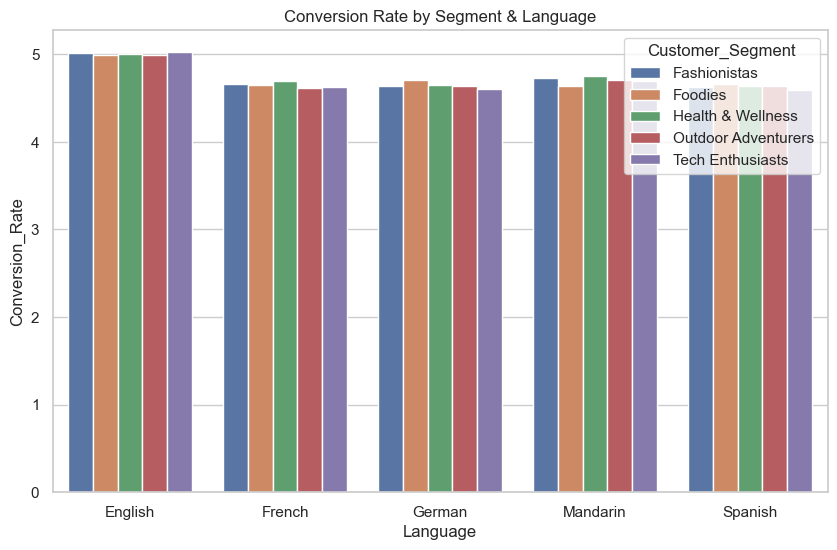

In [91]:
seg_lang = df.groupby(["Language","Customer_Segment"])["Conversion_Rate"].mean().reset_index()

sns.barplot(data=seg_lang, x="Language", y="Conversion_Rate", hue="Customer_Segment")
plt.title("Conversion Rate by Segment & Language")
plt.show()

### 8️⃣ Acquisition Cost Distribution by Segment & Channel

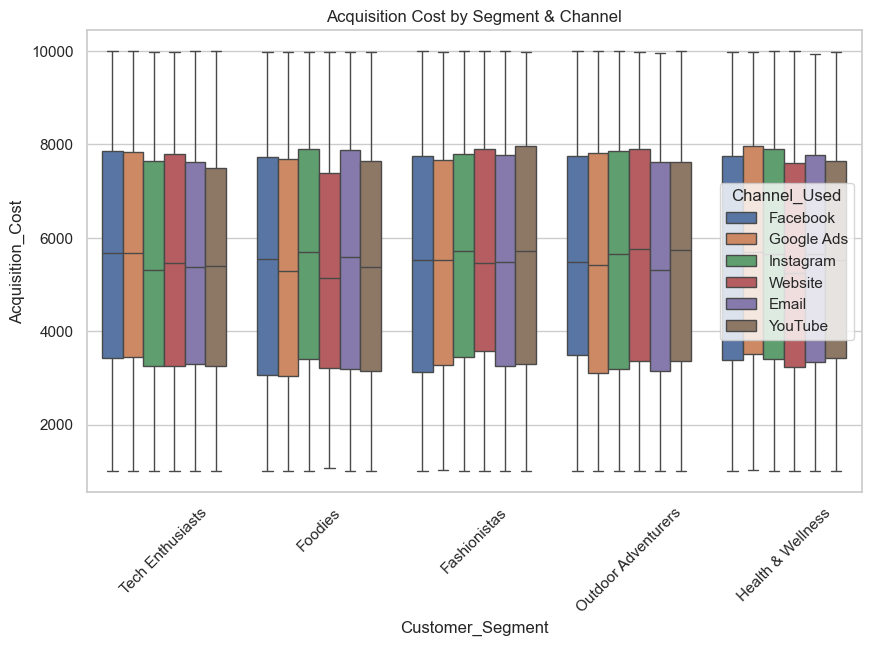

In [93]:
sns.boxplot(data=df, x="Customer_Segment", y="Acquisition_Cost", hue="Channel_Used")
plt.xticks(rotation=45)
plt.title("Acquisition Cost by Segment & Channel")
plt.show()

### 9️⃣ Average Conversion Rate by Language

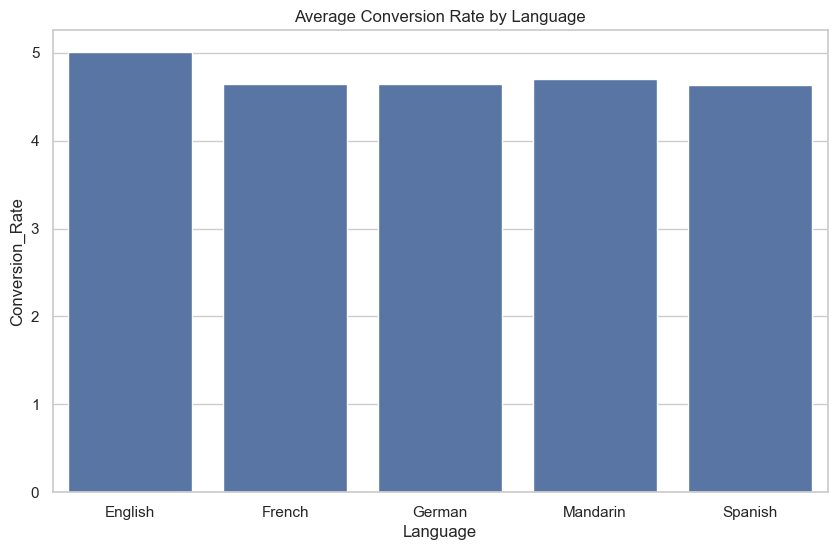

In [95]:
lang_conv = df.groupby("Language")["Conversion_Rate"].mean().reset_index()

sns.barplot(data=lang_conv, x="Language", y="Conversion_Rate")
plt.title("Average Conversion Rate by Language")
plt.show()

### 🔟 Engagement Score by Channel & Campaign Type

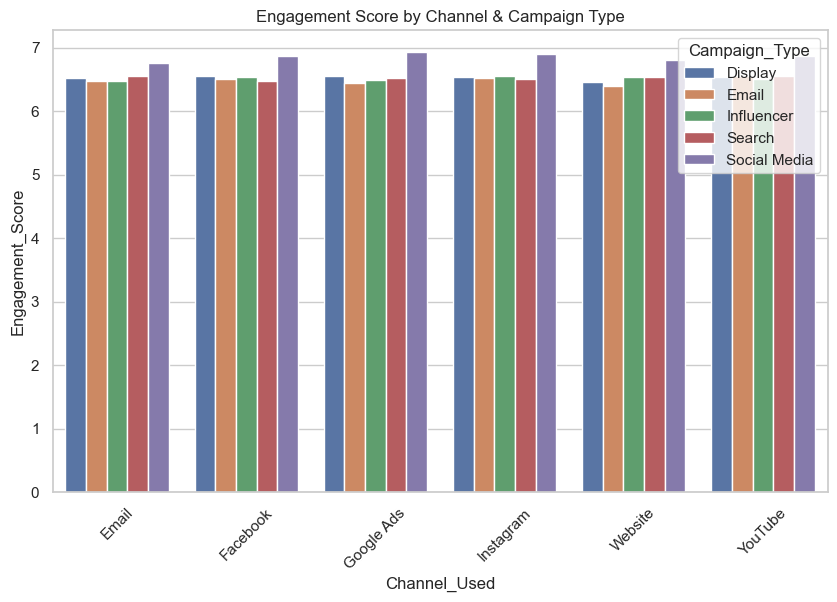

In [97]:
engagement = df.groupby(["Channel_Used","Campaign_Type"])["Engagement_Score"].mean().reset_index()

sns.barplot(data=engagement, x="Channel_Used", y="Engagement_Score", hue="Campaign_Type")
plt.xticks(rotation=45)
plt.title("Engagement Score by Channel & Campaign Type")
plt.show()

### 1️⃣1️⃣ ROI Distribution by Channel (Pie Chart)

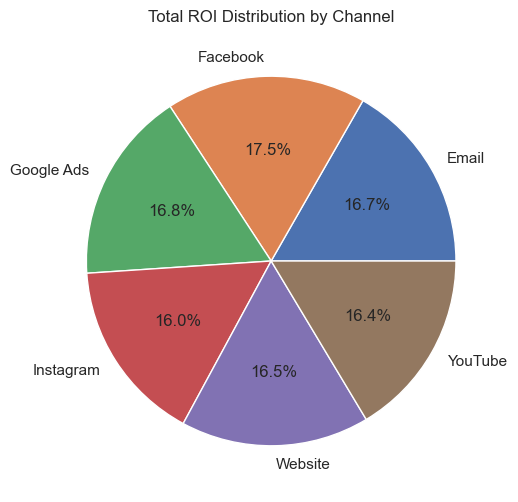

In [99]:
roi_channel = df.groupby("Channel_Used")["ROI"].sum()

plt.pie(roi_channel, labels=roi_channel.index, autopct="%1.1f%%")
plt.title("Total ROI Distribution by Channel")
plt.show()

### 1️⃣2️⃣ Clicks vs Impressions (Scatter)

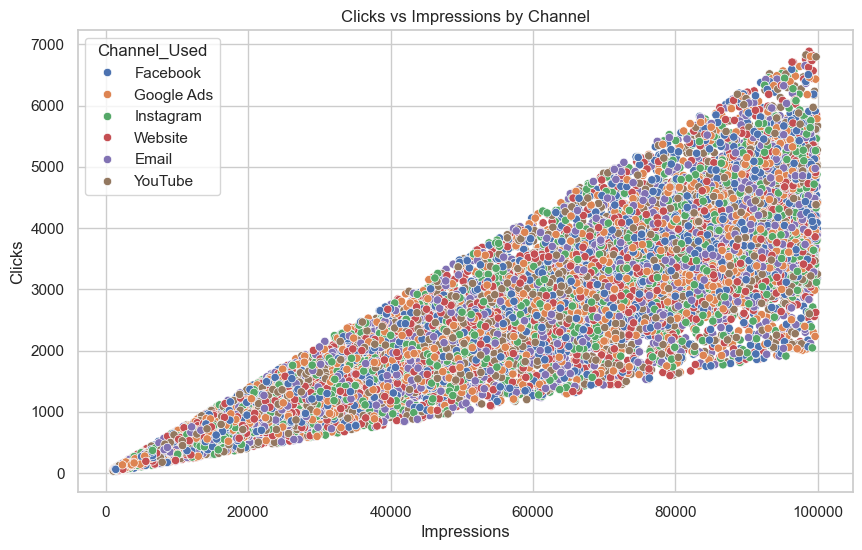

In [101]:
sns.scatterplot(data=df, x="Impressions", y="Clicks", hue="Channel_Used")
plt.title("Clicks vs Impressions by Channel")
plt.show()

### 1️⃣3️⃣ Duration Distribution

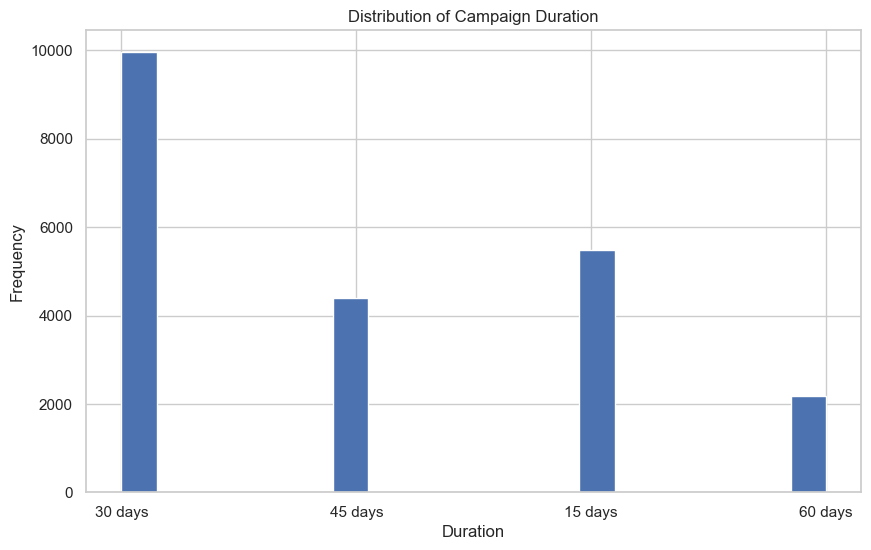

In [103]:
plt.hist(df["Duration"], bins=20)
plt.title("Distribution of Campaign Duration")
plt.xlabel("Duration")
plt.ylabel("Frequency")
plt.show()

### 1️⃣4️⃣ Conversion Rate Over Time by Company

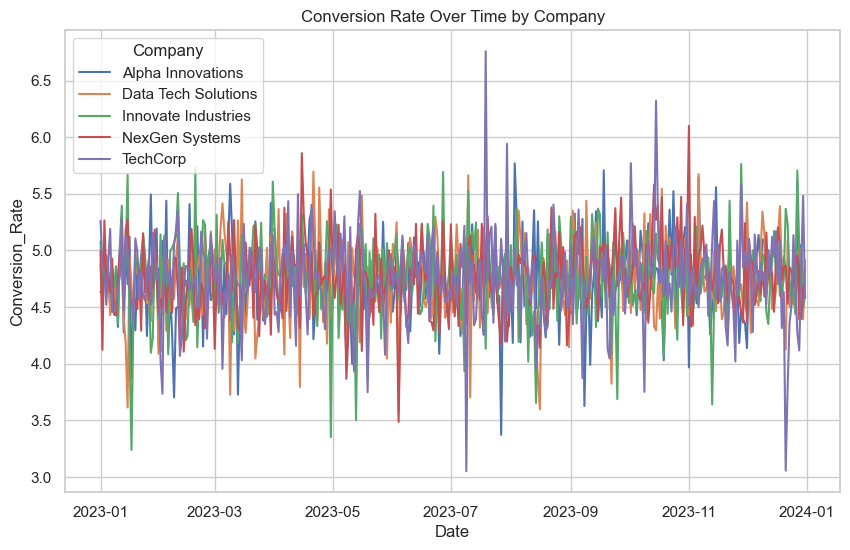

In [105]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

conv_time = df.groupby(["Date","Company"])["Conversion_Rate"].mean().reset_index()

sns.lineplot(data=conv_time, x="Date", y="Conversion_Rate", hue="Company")
plt.title("Conversion Rate Over Time by Company")
plt.show()

### 1️⃣5️⃣ Engagement Score Trend Over Time

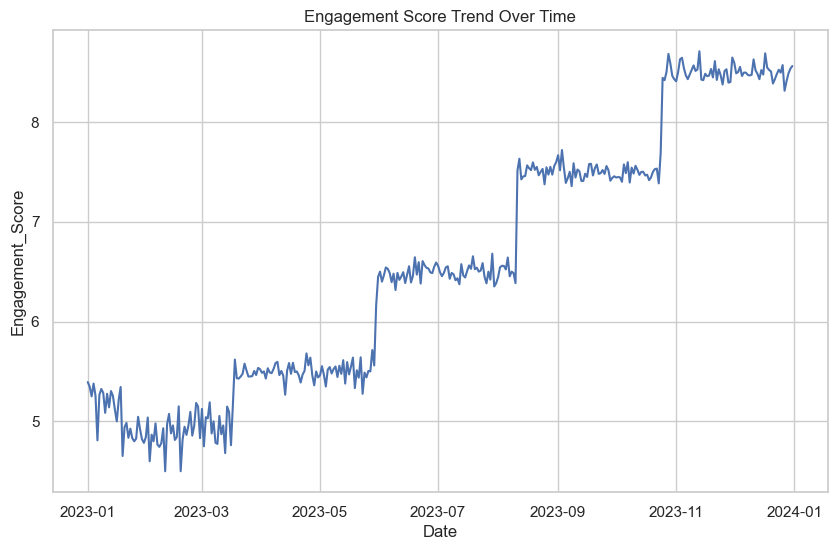

In [107]:
eng_time = df.groupby("Date")["Engagement_Score"].mean().reset_index()

sns.lineplot(data=eng_time, x="Date", y="Engagement_Score")
plt.title("Engagement Score Trend Over Time")
plt.show()

### 1️⃣6️⃣ Highest Acquisition Cost by Location

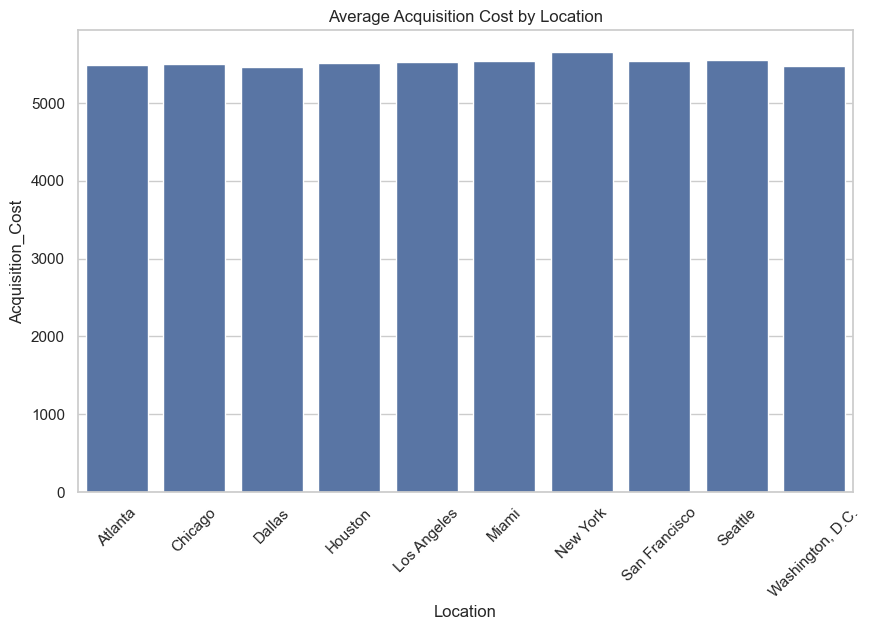

In [109]:
loc_cost = df.groupby("Location")["Acquisition_Cost"].mean().reset_index()

sns.barplot(data=loc_cost, x="Location", y="Acquisition_Cost")
plt.xticks(rotation=45)
plt.title("Average Acquisition Cost by Location")
plt.show()

### 1️⃣7️⃣ Conversion Rate by Location & Target Audience

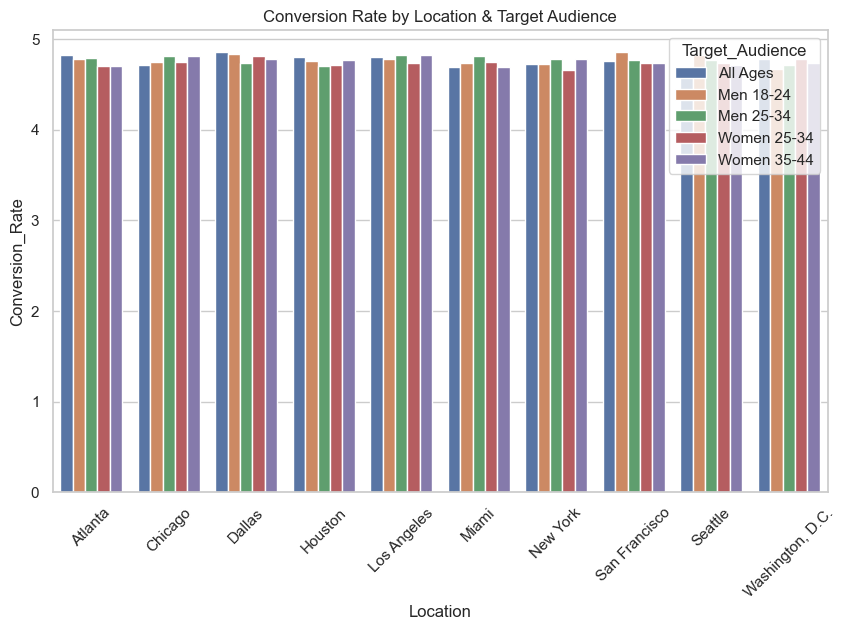

In [111]:
loc_target = df.groupby(["Location","Target_Audience"])["Conversion_Rate"].mean().reset_index()

sns.barplot(data=loc_target, x="Location", y="Conversion_Rate", hue="Target_Audience")
plt.xticks(rotation=45)
plt.title("Conversion Rate by Location & Target Audience")
plt.show()

### 1️⃣8️⃣ ROI Proportion by Location (Pie Chart)

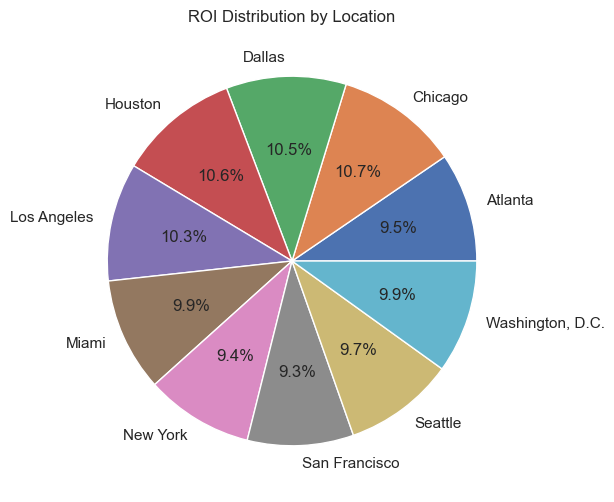

In [113]:
roi_loc = df.groupby("Location")["ROI"].sum()

plt.pie(roi_loc, labels=roi_loc.index, autopct="%1.1f%%")
plt.title("ROI Distribution by Location")
plt.show()